# Ray Calculation

Current step as of Fri Aug 7: Seems to be a units issue or some scale problem for the IAT. Gets bigger instead of smaller

In [1]:
import numpy as np
from astropy import units as u

In [2]:
pwd

'/Users/ibehbehani/csm_pipeline'

In [3]:
import csv

csm_2d_density_list = []
with open("saved_data/csm_2d_density.csv") as csvfile:
    reader = csv.reader(csvfile, quoting=csv.QUOTE_NONNUMERIC) # change contents to floats
    for row in reader: # each row is a list
        csm_2d_density_list.append(row)

In [4]:
csm_2d_density = np.array(csm_2d_density_list)


In [5]:
csm_2d_density[np.isnan(csm_2d_density)] = 0



In [6]:
from matplotlib import pyplot as plt

In [7]:
# get ready to crop out all of the nan vals
center_x = 499
center_y = 499
pix_size_arcsec = 0.005*u.arcsec

In [8]:
lines = 201
points = 100

In [39]:
csm_2d_density[a:b,a:b].shape

(120, 120)

In [9]:
a=440
b=560
#moving center for cropped image
center_interp = int(csm_2d_density[a:b,a:b].shape[0]/2-1)
center_interp

59

Text(0, 0.5, '$\\Delta$ Dec (arc)')

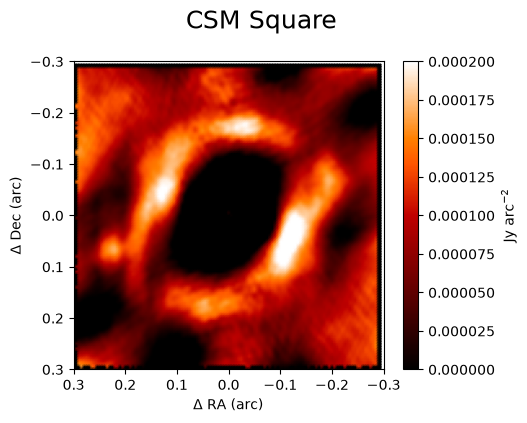

In [10]:
maxx= -0.3
minn = -1*maxx

figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)

xaxis = range(csm_2d_density.shape[0])*pix_size_arcsec-(center_x*pix_size_arcsec)
yaxis = range(csm_2d_density.shape[1])*pix_size_arcsec-(center_y*pix_size_arcsec)

im = ax.pcolormesh(xaxis[a:b],yaxis[a:b],csm_2d_density[a:b,a:b], cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0002)

ax.set_xlim(minn, maxx)
ax.set_ylim(minn, maxx)

figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')

ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)

In [11]:
import sys

In [12]:
np.set_printoptions(threshold=sys.maxsize)

In [13]:
from radial_interpolation import *

hello again


59 59 0.005 arcsec True


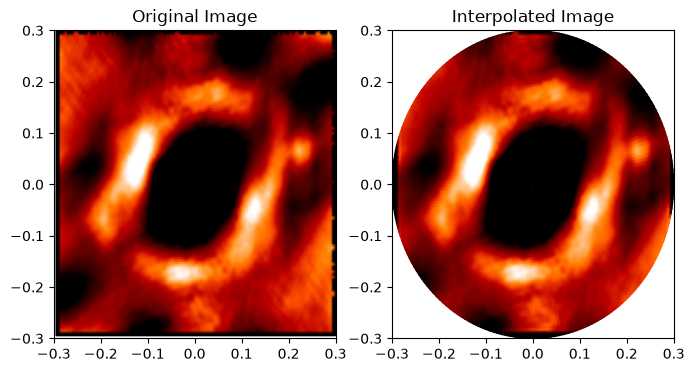

In [14]:
x_grid,y_grid,interp_csm = radial_interp(csm_2d_density[a:b,a:b], center_interp,center_interp,
              n_lines = lines, n_pts = points, pix_arc = pix_size_arcsec,plot_bool=True,vmax=0.0002)

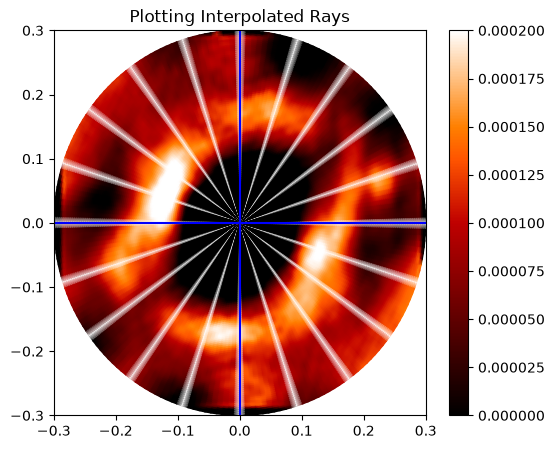

In [15]:
plot_rays(x_grid,y_grid,interp_csm,vmax=0.0002)


# Inverse Abel Transform

In [16]:
from abel import do_abel

In [17]:
from radial import sm

In [18]:
xaxis = x_grid*pix_size_arcsec.value-(center_interp*pix_size_arcsec.value)
yaxis = y_grid*pix_size_arcsec.value-(center_interp*pix_size_arcsec.value)

In [19]:
radius_2d_arc = np.array([[0.0]*xaxis.shape[1]]*xaxis.shape[0])
#fill pc array of radii
for i in range(xaxis.shape[0]):
        for j in range(xaxis.shape[1]):
            c = (xaxis[i,j])**2+(yaxis[i,j])**2
            radius_2d_arc[i,j] = np.sqrt(c)

            # c = (center_interp-np.abs(xaxis[i,j]))**2+(center_interp-np.abs(yaxis[i,j]))**2
            # radius_2d_arc[i,j] = np.sqrt(c)

In [20]:
x_pc = sm(168,xaxis)*u.pc
y_pc = sm(168,yaxis)*u.pc

In [21]:
radius_2d_pc = sm(168,radius_2d_arc)*u.pc

Text(0, 0.5, '$\\Delta$ Dec (arc)')

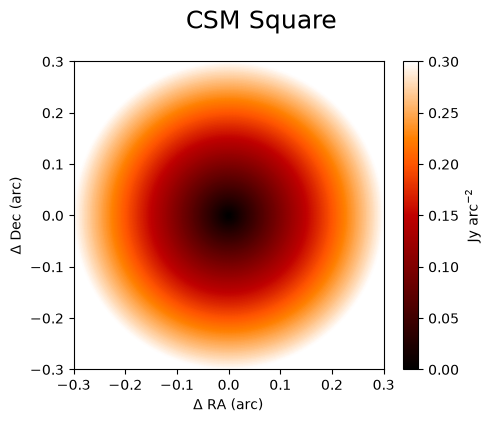

In [22]:
figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)

# xaxis1 = range(csm_2d_density.shape[0])*pix_size_arcsec-(center_x*pix_size_arcsec)
# yaxis1 = range(csm_2d_density.shape[1])*pix_size_arcsec-(center_y*pix_size_arcsec)

im = ax.pcolormesh(xaxis,yaxis,radius_2d_arc, cmap='gist_heat',shading="gouraud")#, vmin = 0, vmax = 0.0002)

# ax.set_xlim(minn, maxx)
# ax.set_ylim(minn, maxx)

figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')

ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)

Text(0, 0.5, '$\\Delta$ (pc))')

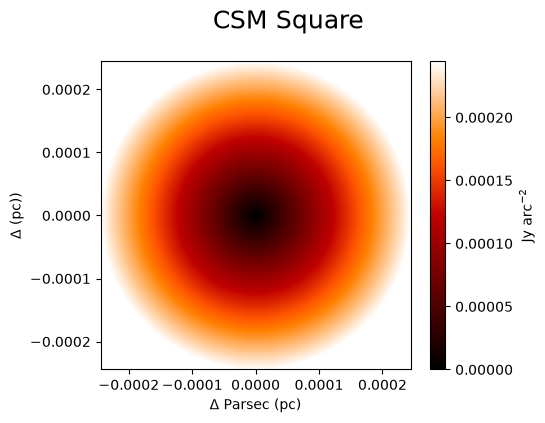

In [23]:
figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)

# xaxis1 = range(csm_2d_density.shape[0])*pix_size_arcsec-(center_x*pix_size_arcsec)
# yaxis1 = range(csm_2d_density.shape[1])*pix_size_arcsec-(center_y*pix_size_arcsec)

im = ax.pcolormesh(x_pc,y_pc,radius_2d_pc.value, cmap='gist_heat',shading="gouraud")#, vmin = 0, vmax = 0.0002)

# ax.set_xlim(minn, maxx)
# ax.set_ylim(minn, maxx)

figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')

ax.set_xlabel(r'$\Delta$ Parsec (pc)' , size = 10)
ax.set_ylabel(r'$\Delta$ (pc))' , size = 10)

In [24]:
def do_abel_2(F_arr,s,med):
    '''
    F = radial profile of surface density
    s = radii corresponding with radial profile
    med = background median- sets all neg values in F array to bkg median
    '''
    #print(F_arr)
    #integrands = np.zeros(len(s))
    #med = med/10
    F = F_arr.copy() # copy density array to prevent overwriting
    F[F<0] = 0#med/1000 # turn negative values into background 0 or median
    dF_ds = np.gradient(F,s) 

    # c =  8#correction

    # f_r = np.zeros(len(s)-c)
    # r_arr = np.zeros(len(s)-c)
    
    # for i in range(len(s)-c):
    
    f_r = np.zeros(len(s))
    r_arr = np.zeros(len(s))
    
    for i in range(len(s)-1):
        
        r = (s[i]+s[i+1])/2 # set r values (3D radial coords) to s (on sky radius) bin centers
        r_arr[i] = r                    # curtails potential div by zero issues

        
        # integrate from r to highest radial value
        integ = np.trapezoid(dF_ds[i+1:]/ np.sqrt(s[s>r]**2-r**2),s[s>r])
        
        # multiply integral result by -1/pi coefficient
        f_r[i]= (-1/np.pi)* integ # integrate from r to highest radial value

    print("\n",i)
    print('f_r len',len(f_r))
    print('r_arr len', len(r_arr))

    print('f_r zeros', np.count_nonzero(f_r==0))
    print('r_arr zeros', np.count_nonzero(r_arr==0))


    return f_r, dF_ds

In [25]:
csm_abel = []
r_arr = np.zeros(len(interp_csm[i,:]))
row = np.zeros(len(interp_csm[i,:]))
radius_abel_arc = []
x_abel_arc = [] # x data assocated w abel transformed data
y_abel_arc = []
m = 0
all_integrands = []
med_dens = 8.7055651*10**-8 #csm median density

df_ds = [] #df/ds filled list
for i in range(len(interp_csm[:,0])):
    #print('i',i)
    row = np.zeros(len(interp_csm[i,:]))

    row,df_ds_temp = do_abel_2(interp_csm[i,:],(radius_2d_pc[i,:].to(u.cm)).value,med_dens/10)
    #print(df_ds_temp.shape)

    df_ds.append(df_ds_temp)
    csm_abel.append(row)



 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100


In [26]:
csm_abel = np.array(csm_abel)

In [27]:
df_ds_array = np.array(df_ds)

In [28]:
c=8

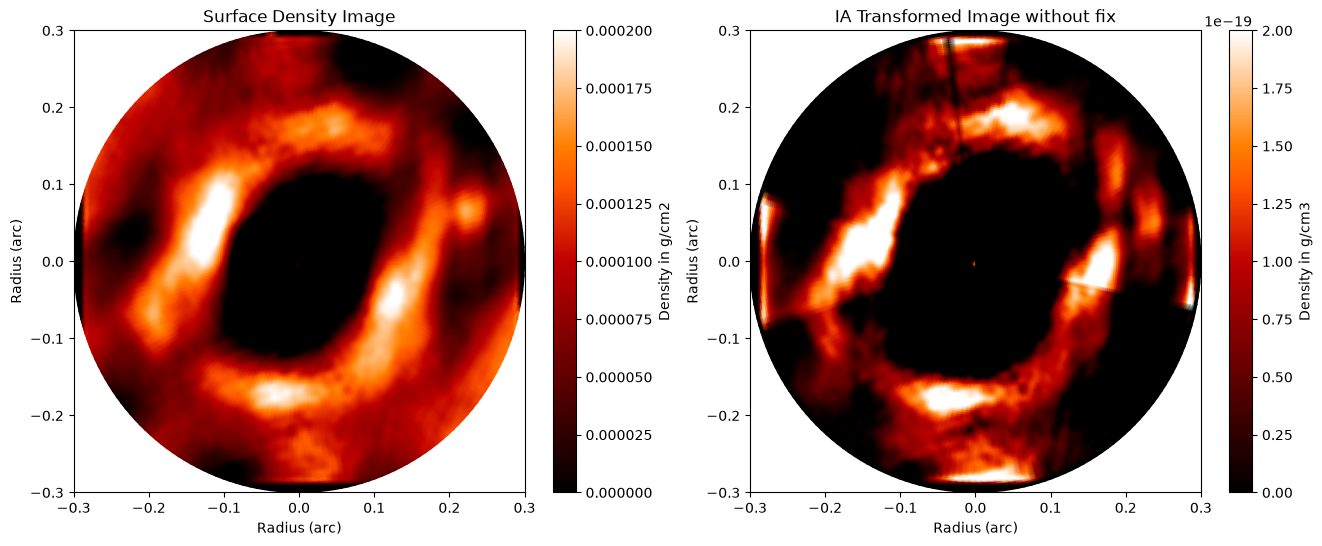

In [29]:
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(16,6))

im0 = ax[0].pcolormesh(xaxis, yaxis, interp_csm,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0002)

rnge = 0.3
ax[0].set_xlim(-rnge,rnge)
ax[0].set_ylim(-rnge,rnge)
ax[0].set_xlabel("Radius (arc)")
ax[0].set_ylabel("Radius (arc)")

ax[0].set_title("Surface Density Image")
fig.colorbar(im0,label = "Density in g/cm2")

### abel image
c=1
#im1 = ax[1].pcolormesh(xaxis[:,0:-c], yaxis[:,0:-c], csm_abel,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 2e-19)
im1 = ax[1].pcolormesh(xaxis, yaxis, csm_abel,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 2e-19)

ax[1].set_xlim(-rnge,rnge)
ax[1].set_ylim(-rnge,rnge)
ax[1].set_xlabel("Radius (arc)")
ax[1].set_ylabel("Radius (arc)")


ax[1].set_title("IA Transformed Image without fix")
fig.colorbar(im1,label = "Density in g/cm3")

In [30]:
#import ipympl

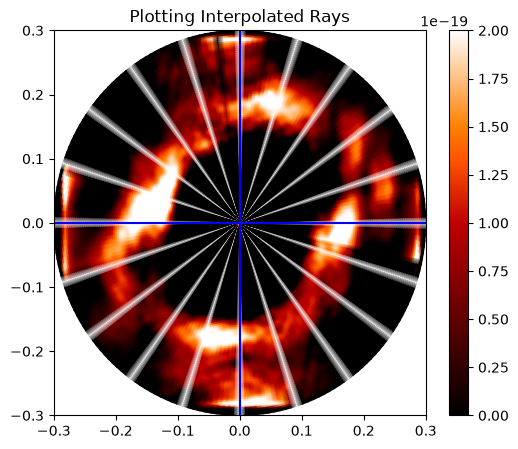

In [31]:
plot_rays(xaxis, yaxis, csm_abel,vmax = 2e-19,shift = False)

In [32]:
radius_2d_arc.shape

(201, 100)

In [33]:
def plot_1d_abel_massloss_bkg(data_abel_1d,info,radius,ax_ymin=1e-2, ax_ymax=1e4,xmin=0,xmax=0.45, suptitle = "1D Abel Transformation (g/cm3)", dent=False):
    '''
    plot 1d density and intensity functions.
    can select plot x and y limits. default values inputted otherwise
    '''

    fig, ax = plt.subplots(1, 1, figsize = [7,4])
    fig.suptitle(suptitle)

    title = ['hr','lr','reproj','csm']
    labels = ['{res}"'.format(res = np.round(info['hr']['kspatres'],3)),
             '{res}"'.format(res = np.round(info['lr']['kspatres'],3)),
               'Reprojected {res}"'.format(res = np.round(info['hr']['kspatres'],3)),
                 "CSM"]    
    
    for j in range(len(title)):
 
        ax.fill_between(radius[title[j]]['arc_1d'][:len(data_abel_1d[title[j]])],data_abel_1d[title[j]]+data_abel_1d[title[j]]*430,data_abel_1d[title[j]]+data_abel_1d[title[j]]*1000,alpha=0.4, label = labels[j], color = color[j])

        #ax.fill_between(radius[title[j]]['arc_1d'][:len(data_abel_1d[title[j]])],data_abel_1d[title[j]]+data_abel_1d[title[j]]*430,data_abel_1d[title[j]]+data_abel_1d[title[j]]*1000,alpha=0.4, label = labels[j], color = color[j])


    x = (radius[title[j]]['arc_1d'][:len(data_abel_1d[title[j]])]).value
    increment = np.arange(0,len(x),x[1]-x[0])
    #y = (data_abel_1d[title[j]][0]*716)*(10)**(-x) #abels['hr'][0]
    y = (data_abel_1d['lr'][0]*716)*10**(-x)
 

    xlr = (radius[title[j]]['arc_1d'][:len(abels['lr'])]).value    
    xlr_cm = (radius[title[j]]['pc_1d'][:len(abels['lr'])]).to(u.cm)    
    xlr_rsun = (radius[title[j]]['pc_1d'][:len(abels['lr'])]).to(u.Rsun)  
    dlr = np.gradient(abels['lr']*716,0.005)
    # # print("dlr", dlr)
    # # print("y!",716*abels['lr'][0]*10**(dlr*xlr))

    v_yr = (1e6*u.cm/u.s).to(u.cm/u.yr)
    v_s = (1e6*u.cm/u.s)

    #Mlr = radius3['lr']['pc_1d'].to(u.cm)**2* (716*abels['lr']*u.g/u.cm**3).to(u.M_sun/u.cm**3) *4*np.pi*(1e6*u.cm/u.s).to(u.cm/u.yr)
    
    #ax.plot(xlr, Mlr.to(u.g/u.s) / (4*np.pi*xlr_cm**2*v_s), label = r'$\dot M = 4 \pi r^2 \rho v$')


    mdotexp = [-8,-7,-6,-5,-4]# msun/yr

    for mdot in mdotexp:
        print(mdot)

        rho_mdot = 10**mdot*u.M_sun/u.yr / (4*np.pi*xlr_cm**2*v_yr)
        ax.plot(xlr, rho_mdot.to(u.g/u.cm**3).value, ls  = '-.',alpha = 0.6, c='grey')

        xtext = xlr[1]
        ytext = rho_mdot[35].to(u.g/u.cm**3)+rho_mdot[1].to(u.g/u.cm**3)/13

        print(xtext,ytext)


        ax.text(xtext,ytext, f'$10^{{{mdot}}}$'+r' $M_\odot yr^{-1}$', fontsize=9, 
                rotation=-20, alpha = 0.6)


    # ax.plot(xlr, 716*abels['lr'][0]*10**(dlr*xlr), color = 'gray', ls  = '--', label = 'LR deriv ~10**(-13)')
    ax.legend(loc = 'upper right')#, bbox_to_anchor=(.85, 0.5, 0.5, 0.5))
    ax.semilogy()
    ax.semilogx()
#     ax.set_title("1-D Density (g/cm3)")
    ax.set_xlim(xmin,xmax)
    ax.set_ylim(ax_ymin, ax_ymax)


    ax.set_xlabel('Radius (arcseconds)')
    ax.set_ylabel(r'Density (g cm$^{-3}$)')

In [34]:
radius_2d_pc.to(u.cm)

<Quantity [[0.00000000e+00, 7.61588445e+12, 1.52317689e+13,
            2.28476533e+13, 3.04635378e+13, 3.80794222e+13,
            4.56953067e+13, 5.33111911e+13, 6.09270756e+13,
            6.85429600e+13, 7.61588445e+13, 8.37747289e+13,
            9.13906133e+13, 9.90064978e+13, 1.06622382e+14,
            1.14238267e+14, 1.21854151e+14, 1.29470036e+14,
            1.37085920e+14, 1.44701804e+14, 1.52317689e+14,
            1.59933573e+14, 1.67549458e+14, 1.75165342e+14,
            1.82781227e+14, 1.90397111e+14, 1.98012996e+14,
            2.05628880e+14, 2.13244764e+14, 2.20860649e+14,
            2.28476533e+14, 2.36092418e+14, 2.43708302e+14,
            2.51324187e+14, 2.58940071e+14, 2.66555956e+14,
            2.74171840e+14, 2.81787724e+14, 2.89403609e+14,
            2.97019493e+14, 3.04635378e+14, 3.12251262e+14,
            3.19867147e+14, 3.27483031e+14, 3.35098916e+14,
            3.42714800e+14, 3.50330684e+14, 3.57946569e+14,
            3.65562453e+14, 3.73178338e+

In [35]:
radius_2d_arc.shape

(201, 100)

/opt/anaconda3/envs/myenv/lib/python3.14/site-packages/astropy/units/quantity.py:676: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


(1e-20, 1e-12)

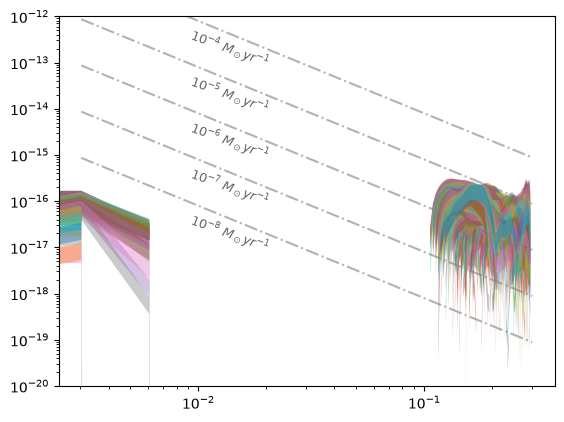

In [36]:
for i in range(radius_2d_arc.shape[0]):
    #plt.plot(radius_2d_arc[i,], csm_abel[i,])
    plt.fill_between(radius_2d_arc[i,],csm_abel[i,]+csm_abel[i,]*430,csm_abel[i,]+csm_abel[i,]*1000,alpha=0.4)

mdotexp = [-8,-7,-6,-5,-4]# msun/yr
v_yr = (1e6*u.cm/u.s).to(u.cm/u.yr)

for mdot in mdotexp:
    #print(mdot)

    rho_mdot = 10**mdot*u.M_sun/u.yr / (4*np.pi*radius_2d_pc[0,].to(u.cm)**2*v_yr)
    plt.plot(radius_2d_arc[0,], rho_mdot.to(u.g/u.cm**3).value, ls  = '-.',alpha = 0.6, c='grey')

    xtext = radius_2d_arc[0,3]
    ytext = rho_mdot[35].to(u.g/u.cm**3)+rho_mdot[1].to(u.g/u.cm**3)/120

    #print(xtext,ytext)


    plt.text(xtext,ytext, f'$10^{{{mdot}}}$'+r' $M_\odot yr^{-1}$', fontsize=9, 
            rotation=-20, alpha = 0.6)

plt.semilogy()
plt.semilogx()
plt.ylim(10**-20,10**-12)

In [37]:
csm_abel_zero = np.zeros_like(csm_abel)
for i in range(radius_2d_arc.shape[0]):
    for j in range(radius_2d_arc.shape[1]):
        if radius_2d_arc[i,j]>0.1:
            csm_abel_zero[i,j]=csm_abel[i,j]

(1e-20, 1e-12)

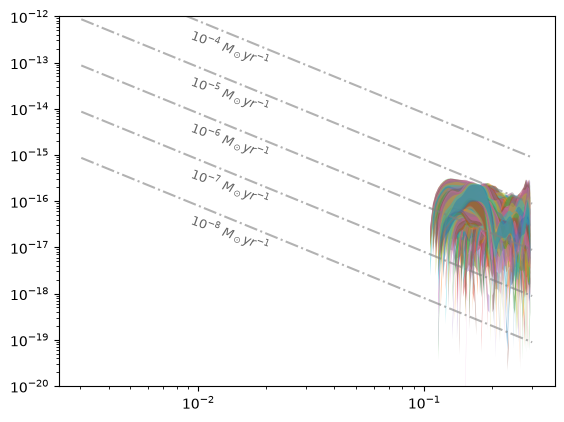

In [38]:
for i in range(radius_2d_arc.shape[0]):
    #plt.plot(radius_2d_arc[i,], csm_abel[i,])
    plt.fill_between(radius_2d_arc[i,],csm_abel_zero[i,]+csm_abel_zero[i,]*430,csm_abel_zero[i,]+csm_abel_zero[i,]*1000,alpha=0.4)

mdotexp = [-8,-7,-6,-5,-4]# msun/yr
v_yr = (1e6*u.cm/u.s).to(u.cm/u.yr)

for mdot in mdotexp:
    #print(mdot)

    rho_mdot = 10**mdot*u.M_sun/u.yr / (4*np.pi*radius_2d_pc[0,].to(u.cm)**2*v_yr)
    plt.plot(radius_2d_arc[0,], rho_mdot.to(u.g/u.cm**3).value, ls  = '-.',alpha = 0.6, c='grey')

    xtext = radius_2d_arc[0,3]
    ytext = rho_mdot[35].to(u.g/u.cm**3)+rho_mdot[1].to(u.g/u.cm**3)/120

    #print(xtext,ytext)


    plt.text(xtext,ytext, f'$10^{{{mdot}}}$'+r' $M_\odot yr^{-1}$', fontsize=9, 
            rotation=-20, alpha = 0.6)

plt.semilogy()
plt.semilogx()
plt.ylim(10**-20,10**-12)